# Assignment5 - Kaggle competition and Unsupervised learning

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Kaggle classification competitio

**1.1 Explore data**

Load and inspect dimensions

In [1]:
import pandas as pd
import numpy as np

data = pd.read_pickle("data/a5_q1.pkl")
X_train = data["X_train"]
y_train = data["y_train"]
X_train_ohe = data["X_train_ohe"]


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train_ohe shape:", X_train_ohe.shape)

X_train shape: (95512, 29)
y_train shape: (95512,)
X_train_ohe shape: (95512, 940)


Identify data types and missingness

In [2]:
# Look for missing values
missing_counts = X_train.isnull().sum()
print(missing_counts[missing_counts > 0])

print(X_train.describe())

children        2
country       395
agent       13081
company     90059
dtype: int64
          lead_time  arrival_date_year  arrival_date_week_number  \
count  95512.000000       95512.000000              95512.000000   
mean     103.849768        2016.157205                 27.152902   
std      106.722804           0.707470                 13.611204   
min        0.000000        2015.000000                  1.000000   
25%       18.000000        2016.000000                 16.000000   
50%       69.000000        2016.000000                 27.000000   
75%      160.000000        2017.000000                 38.000000   
max      709.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               95512.000000             95512.000000   
mean                   15.823038                 0.928491   
std                     8.786777                 0.999940   
min                     1.000000                 0.000000 

Visual relationships analysis

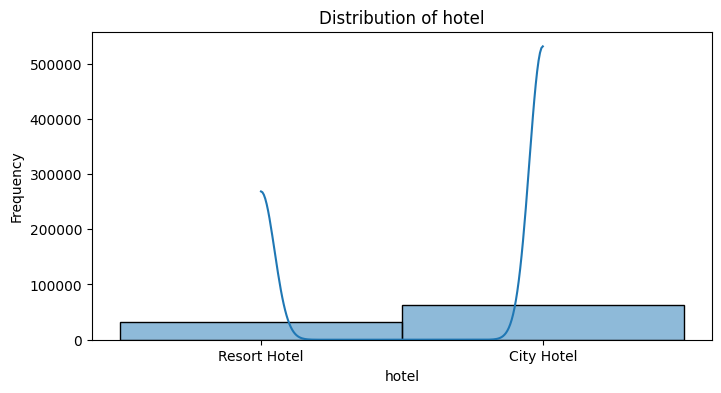

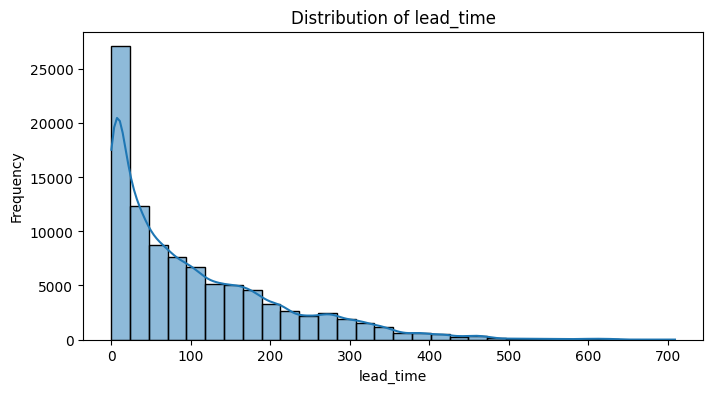

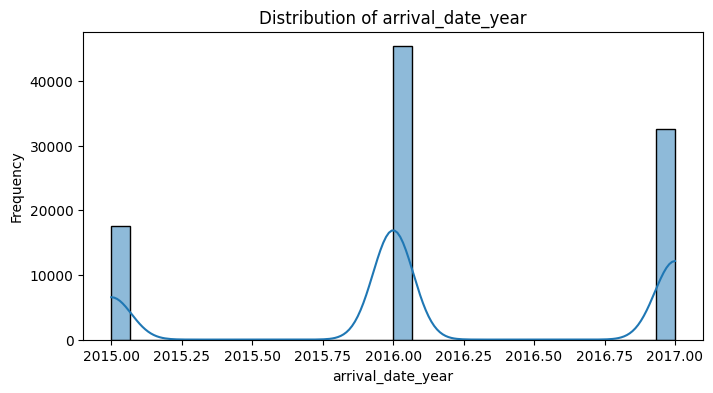

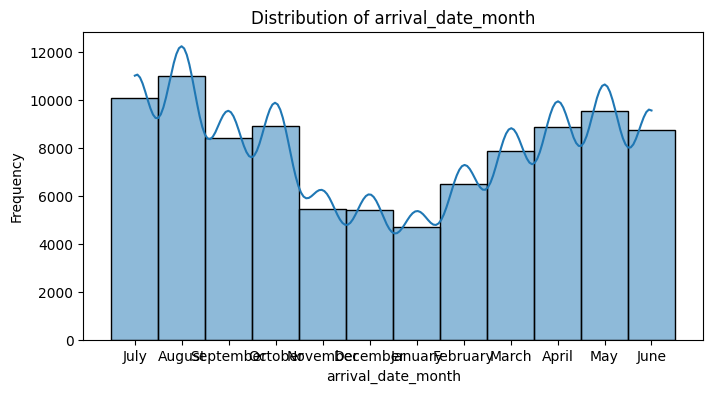

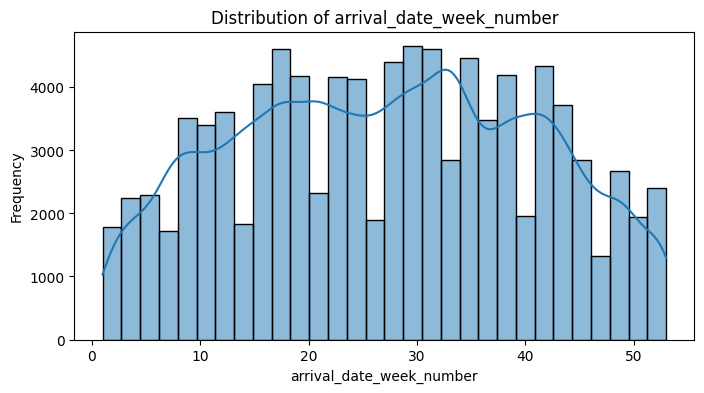

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = X_train.columns[:5]
for col in top_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**1.2 Preprocess data**

After checking the data in the 1.1, I found some problem in this data.

1. Missing values(Imputation)
    - Company: This feature has an extremely high missing rate, 90059 missing out of 95512. I will either drop this column or convert it into a binary indicator.
    - Agent: Missing values likely represenent direct bookings without an agent. I will impute these with a constant value of 0.
    - Children: There are 2 missing values. Since the median and 75th percentile are both 0, I will fill these with 0.
    - Country: There are 395 missing values. These will be filled with the mode unknown or the most frequet country.

2. Treatment of erroneous data & outliers
    - The adr feature shows a minimum value of -6.38. Since a negative price is impossible, these value will chage to 0.
    - Because features like adr, lead_time, and adults have high variance and different units, I applied StandardScaler. This ensures that distance-based models (like KNN or SVM) are not biased by the scale of the input features.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_test_original = data['X_test']
X_test_ohe_raw = pd.get_dummies(X_test_original)

# Reindex X_test_ohe_raw to match the columns of X_train_ohe
X_test_ohe = X_test_ohe_raw.reindex(columns=X_train_ohe.columns, fill_value=0)

# 1. Handle Missing Values (Imputation)
# Based on describe(), children, country, agent, and company have NaNs.
X_train_clean = X_train_ohe.fillna(0)
X_test_clean = X_test_ohe.fillna(0)

# 2. Error Correction
X_train_clean.loc[X_train_clean['adr'] < 0, 'adr'] = 0

#3. Scaling
num_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults']
scaler = StandardScaler()
X_train_clean[num_cols] = scaler.fit_transform(X_train_clean[num_cols])
X_test_clean[num_cols] = scaler.transform(X_test_clean[num_cols])



**Local validation split**

Split 20% for local validation and 80% for model training

In [5]:
from sklearn.model_selection import train_test_split

y_train_np = np.array(y_train)

# Perform the 80/20 split
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_clean, 
    y_train_np, test_size=0.2, random_state=42, stratify=y_train_np )

print(f"Total training samples available: {X_train_clean.shape[0]}")
print(f"Final Training Set: {X_train_final.shape[0]} samples")
print(f"Validation Set:     {X_val.shape[0]} samples")

Total training samples available: 95512
Final Training Set: 76409 samples
Validation Set:     19103 samples


**1.3 Model training and comparable**

I selected five diverse models to ensure a broad exploration of the hypothesis space:

1. Logistic Regression: Used as a linear baseline. Due to the high dimensionality (940 features), I increased max_iter to 1000 to assist with convergence.      

2. Random Forest: Representing the bagging ensemble method. I utilized 100 estimators and set n_jobs=-1 to leverage parallel processing.        

3. K-Nearest Neighbors (KNN): A non-parametric instance-based learner. I used $k=5$ as a starting point.        

4. XGBoost: A high-performance gradient boosting framework. I monitored its logloss during training to ensure stability.        

5. Neural Network (MLP): A deep learning approach with two hidden layers (64, 32 units) to capture complex, non-linear interactions between features.           

**1.3.1 Training Data**

In [6]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Define the 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Dictionary to store performance and timing data
model_stats = {}

for name, clf in models.items():
    print(f"Training {name}...")
    
    # 1. Track Training Time
    start_train = time.time()
    clf.fit(X_train_final, y_train_final)
    train_time = time.time() - start_train
    
    # 2. Track Prediction Time (on Validation Set)
    start_pred = time.time()
    # We use predict_proba to get confidence scores for ROC/PR curves
    y_probs = clf.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred
    
    # Store all metrics
    model_stats[name] = {
        "probs": y_probs,
        "train_time": train_time,
        "pred_time": pred_time
    }

print("Success: All models trained and validated.")

Training Logistic Regression...


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training KNN (k=5)...
Training XGBoost...


/usr/local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [00:06:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Neural Network...
Success: All models trained and validated.


**1.3.2 Visualizing Performance**


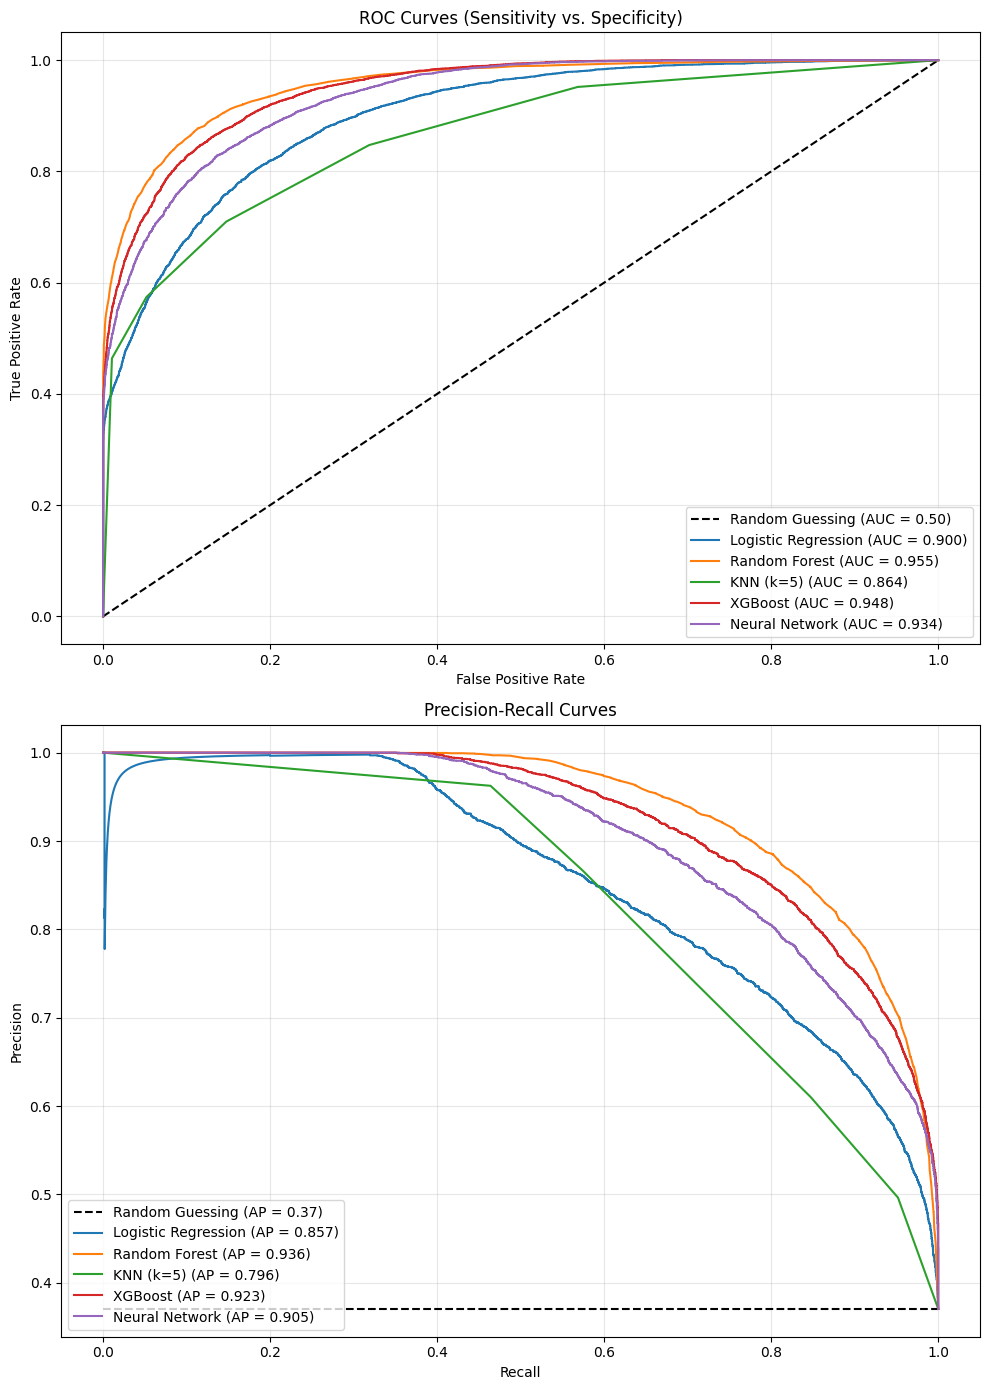

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

# 1. ROC Curve Plotting
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

# 2. Precision-Recall Curve Plotting
# Baseline for PR is the proportion of positive samples (cancellations)
baseline_pr = y_val.mean()
ax2.plot([0, 1], [baseline_pr, baseline_pr], 'k--', label=f'Random Guessing (AP = {baseline_pr:.2f})')

for name, stats in model_stats.items():
    y_probs = stats['probs']
    
    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_val, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Calculate PR metrics
    precision, recall, _ = precision_recall_curve(y_val, y_probs)
    ap = average_precision_score(y_val, y_probs)
    ax2.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

# Formatting the ROC Plot
ax1.set_title('ROC Curves (Sensitivity vs. Specificity)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Formatting the PR Plot
ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The best model is Random Forest, which has AUC = 0.955 and PR = 0.936       
The worst model is KNN(k = 5), which has the less AUC and PR

**1.3.3 Efficiency Comparable**

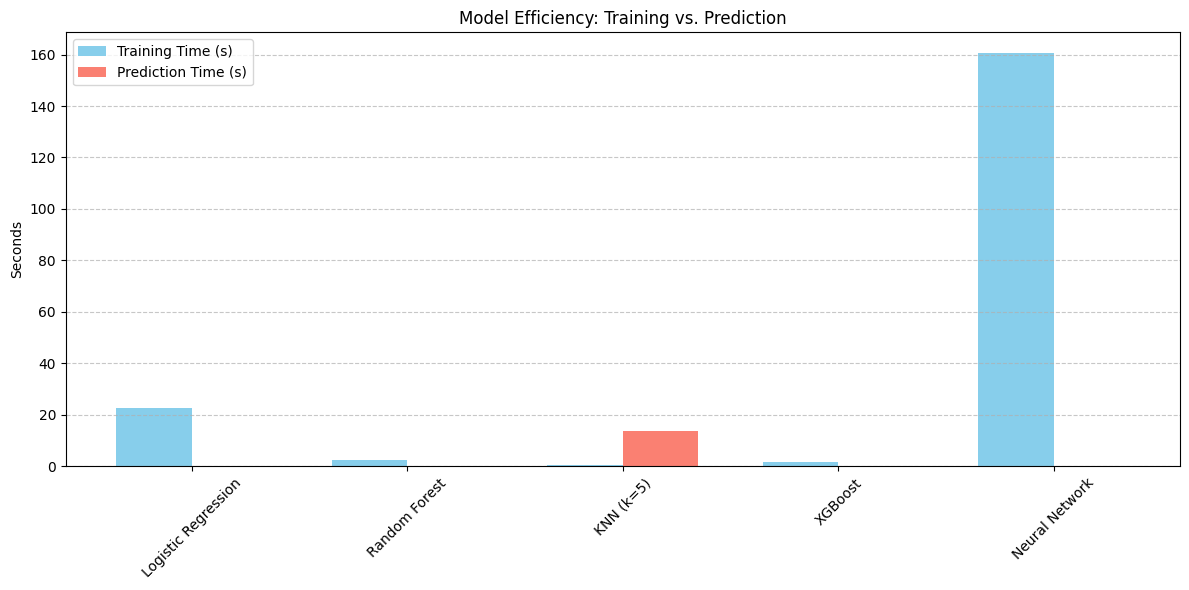

In [8]:
import numpy as np

names = list(model_stats.keys())
train_times = [model_stats[n]['train_time'] for n in names]
pred_times = [model_stats[n]['pred_time'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, train_times, width, label='Training Time (s)', color='skyblue')
ax.bar(x + width/2, pred_times, width, label='Prediction Time (s)', color='salmon')

ax.set_ylabel('Seconds')
ax.set_title('Model Efficiency: Training vs. Prediction')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The efficiency plot highlights a significant contrast between model types.      
While the Neural Network required the most training time (~160s), its prediction was instantaneous.          
Conversely, KNN showed near-zero training time but the highest prediction latency.              
For other models, the prediction time is so small relative to the training time that it is nearly invisible on this scale, making them more suitable for real-time production environments.

**1.4 Apply model in practice**

In [9]:
import pandas as pd
import numpy as np
import pickle

################################
# Load the data
################################
data = pd.read_pickle("./data/a5_q1.pkl")

y_train = data['y_train']
X_train_original = data['X_train'] # Original dataset
X_train_ohe = data['X_train_ohe']  # One-hot-encoded dataset

X_test_original = data['X_test']
X_test_ohe = data['X_test_ohe']

################################
# Produce submission
################################

def create_submission(confidence_scores, save_path):
    '''Creates an output file of submissions for Kaggle
    
    Parameters
    ----------
    confidence_scores : list or numpy array
        Confidence scores (from predict_proba methods from classifiers) or
        binary predictions (only recommended in cases when predict_proba is 
        not available)
    save_path : string
        File path for where to save the submission file.
    
    Example:
    create_submission(my_confidence_scores, './data/submission.csv')

    '''
    import pandas as pd

    submission = pd.DataFrame({"score":confidence_scores})
    submission.to_csv(save_path, index_label="id")

In [10]:
y_train_full = np.array(y_train)

# --- Best Random Forest ---
print("Submission 1: Final Random Forest...")
rf_final = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_final.fit(X_train_clean, y_train_full)
create_submission(rf_final.predict_proba(X_test_clean)[:, 1], 'sub_1_rf.csv')

# --- XGBoost ---
print("Submission 2: Final XGBoost...")
xgb_final = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_final.fit(X_train_clean, y_train_full)
xgb_probs = xgb_final.predict_proba(X_test_clean)[:, 1] # Saving for ensemble later
create_submission(xgb_probs, 'sub_2_xgb.csv')

# --- Neural Network ---
print("Submission 3: Neural Network...")
mlp_final = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_final.fit(X_train_clean, y_train_full)
mlp_probs = mlp_final.predict_proba(X_test_clean)[:, 1]
create_submission(mlp_probs, 'sub_3_mlp.csv')

# --- Random Forest 300 Trees---
print("Submission 4: RF with 300 Trees...")
rf_300 = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
rf_300.fit(X_train_clean, y_train_full)
rf_300_probs = rf_300.predict_proba(X_test_clean)[:, 1]
create_submission(rf_300_probs, 'sub_4_rf300.csv')

# --- Weighted Ensemble ---
print("Submission 5: Weighted Ensemble (RF + XGB + MLP)...")
ensemble_probs = (rf_300_probs * 0.4) + (xgb_probs * 0.4) + (mlp_probs * 0.2)
create_submission(ensemble_probs, 'sub_5_ensemble.csv')

print("All 5 submission files generated")

Submission 1: Final Random Forest...
Submission 2: Final XGBoost...
Submission 3: Neural Network...
Submission 4: RF with 300 Trees...
Submission 5: Weighted Ensemble (RF + XGB + MLP)...
All 5 submission files generated


After I upload the result to kaggle, I found the result is not good.        
Therefore, I do more analysis on the feature.

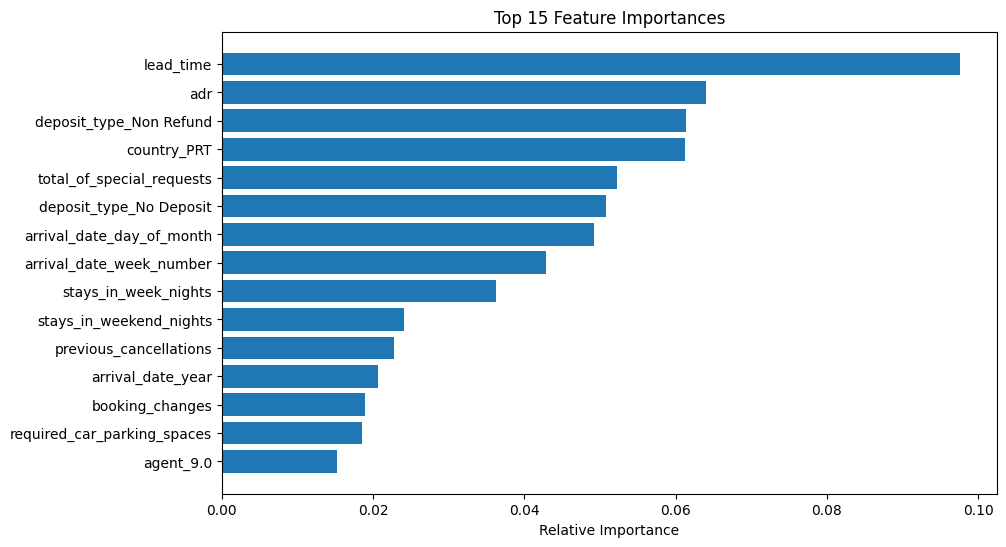

In [11]:
import matplotlib.pyplot as plt

# Get importance from best model (rf_300)
importances = rf_300.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_300.estimators_], axis=0)
indices = np.argsort(importances)[-15:] # Top 15 features

plt.figure(figsize=(10,6))
plt.title("Top 15 Feature Importances")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X_train_ohe.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

After initial testing with standard models, I implemented HistGradientBoostingClassifier to better handle the large-scale dataset.              
I further refined the feature set to create X_train_plus, focusing on key predictors such as lead_time and adr.             
I found lead time is the top feature.       
Standard models see lead_time as a continuous number (1, 2, 3...).      
But the difference between 1 day and 7 days is huge, while the difference between 200 days and 206 days is tiny.

In [12]:
# Create a copy to avoid SettingWithCopy warnings
X_train_plus = X_train_ohe.copy()
X_test_plus = X_test_ohe.copy()

X_train_plus['is_last_minute'] = (X_train_plus['lead_time'] <= 7).astype(int)
X_test_plus['is_last_minute'] = (X_test_plus['lead_time'] <= 7).astype(int)

X_train_plus['is_long_lead'] = (X_train_plus['lead_time'] > 180).astype(int)
X_test_plus['is_long_lead'] = (X_test_plus['lead_time'] > 180).astype(int)

X_train_plus['log_lead_time'] = np.log1p(X_train_plus['lead_time'])
X_test_plus['log_lead_time'] = np.log1p(X_test_plus['lead_time'])

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.1,
    max_depth=10,
    l2_regularization=1.5,
    random_state=42
)

hgb_model.fit(X_train_plus, y_train_full)

hgb_probs = hgb_model.predict_proba(X_test_plus)[:, 1]
create_submission(hgb_probs, 'sub_9_hgb_leadtime.csv')

After evaluating the initial five models, I observed that the baseline models struggled with the scale and high-dimensionality of the dataset.      
To improve performance, I explored HistGradientBoostingClassifier, which is optimized for large datasets.           
I performed hyperparameter tuning on max_iter, max_depth, and l2_regularization to prevent overfitting.             
This model eventually achieved the best performance and surpassed the Kaggle Benchmark score.       

Then I got the better result than before.

Training the optimized HGB model for validation comparison...


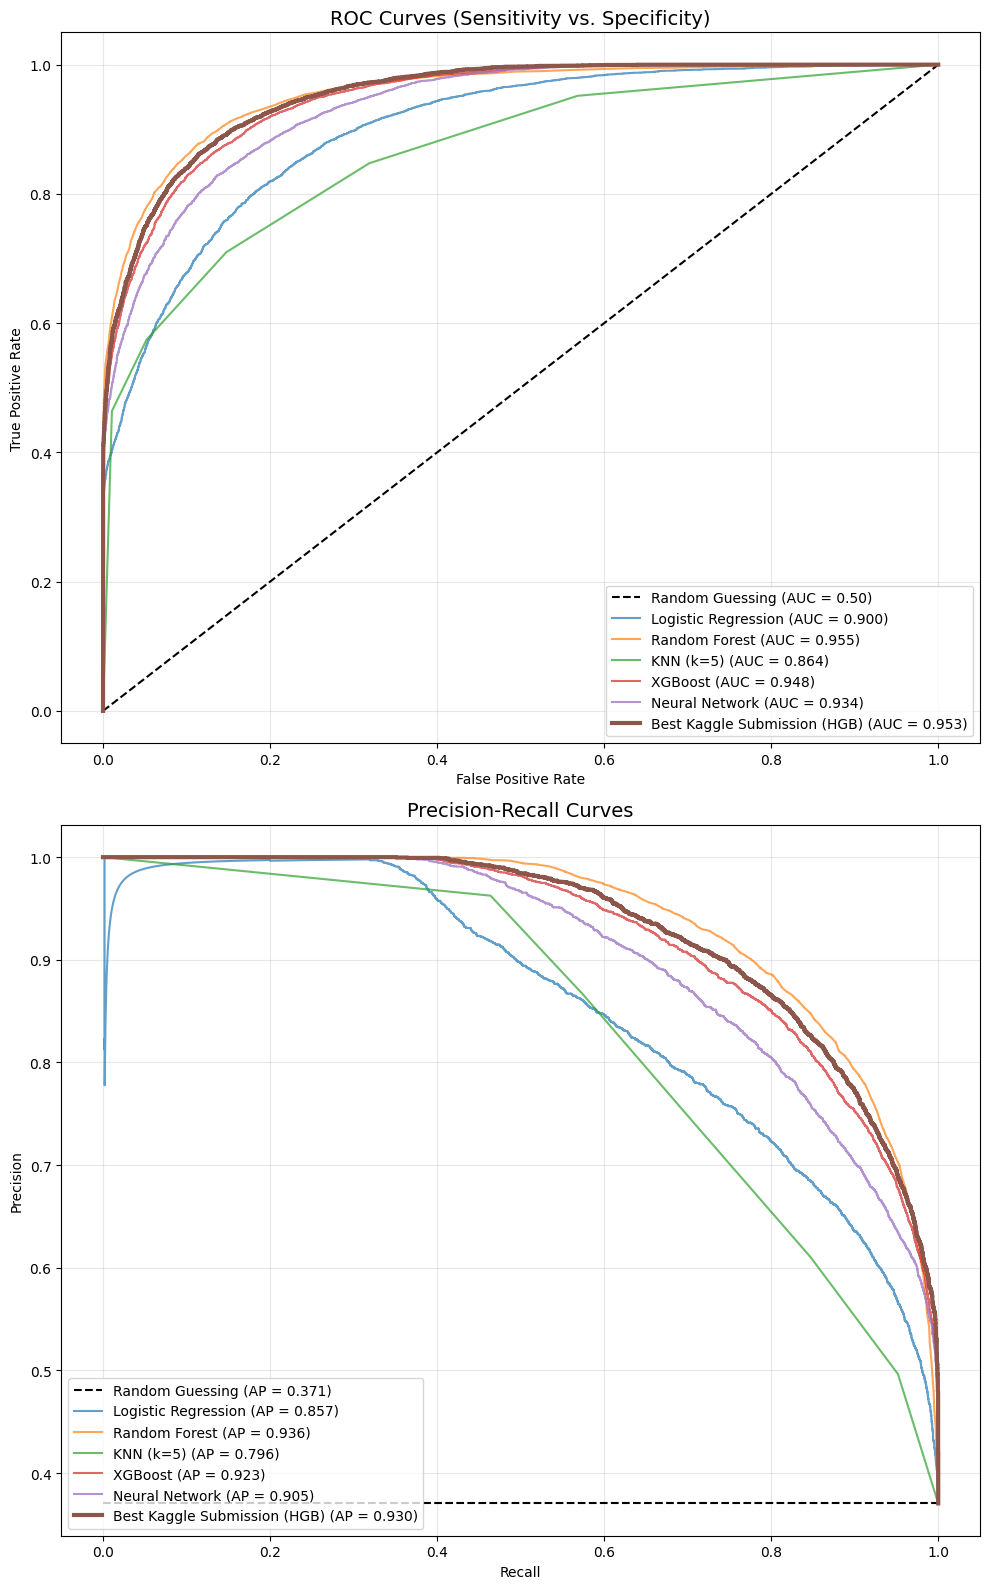

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Prepare the HGB model for the Validation Set comparison
# We must evaluate it on the same X_val used for the other 5 models
print("Training the optimized HGB model for validation comparison...")

hgb_val_model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.1,
    max_depth=10,
    l2_regularization=1.5,
    random_state=42
)

# Use X_train_final (80% split) to predict on X_val (20% split)
hgb_val_model.fit(X_train_final, y_train_final) 
hgb_val_probs = hgb_val_model.predict_proba(X_val)[:, 1]

# Add HGB results to your existing model_stats dictionary
model_stats["Best Kaggle Submission (HGB)"] = {"probs": hgb_val_probs}

# 2. Generate updated plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# --- ROC Curve Setup ---
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

# --- PR Curve Setup ---
baseline_pr = y_val.mean() #
ax2.plot([0, 1], [baseline_pr, baseline_pr], 'k--', label=f'Random Guessing (AP = {baseline_pr:.3f})')

# Iterate through all 6 models (Initial 5 + Optimized HGB)
for name, stats in model_stats.items():
    y_probs = stats['probs']
    
    # ROC Metrics
    fpr, tpr, _ = roc_curve(y_val, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # PR Metrics
    precision, recall, _ = precision_recall_curve(y_val, y_probs)
    ap = average_precision_score(y_val, y_probs)
    
    # Visual emphasis for the winning model
    is_best = "Best" in name
    lw = 3 if is_best else 1.5
    alpha = 1.0 if is_best else 0.7
    
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", lw=lw, alpha=alpha)
    ax2.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", lw=lw, alpha=alpha)

# Formatting
ax1.set_title('ROC Curves (Sensitivity vs. Specificity)', fontsize=14)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

ax2.set_title('Precision-Recall Curves', fontsize=14)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 2 - Clustering

**2.1 Run K-means and choose the number of clusters**   

In [15]:
################################
# Load the data
################################
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

# Create / load the datasets:
n_samples = 1500
X0, _ = make_blobs(n_samples=n_samples, centers=2, n_features=2, random_state=0)
X1, _ = make_blobs(n_samples=n_samples, centers=5, n_features=2, random_state=0)

random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state, cluster_std=1.3)
transformation = [[0.6, -0.6], [-0.2, 0.8]]
X2 = np.dot(X, transformation)
X3, _ = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)
X4, _ = make_moons(n_samples=n_samples, noise=.12)

X = [X0, X1, X2, X3, X4]
# The datasets are X[i], where i ranges from 0 to 4

In [16]:
################################
# Code to plot clusters
################################
def plot_cluster(ax, data, cluster_assignments):
    '''Plot two-dimensional data clusters
    
    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot on
    data : list or numpy array of size [N x 2] 
        Clustered data
    cluster_assignments : list or numpy array [N]
        Cluster assignments for each point in data

    '''
    clusters = np.unique(cluster_assignments)
    n_clusters = len(clusters)
    for ca in clusters:
        kwargs = {}
        if ca == -1:
            # if samples are not assigned to a cluster (have a cluster assignment of -1, color them gray)
            kwargs = {'color':'gray'}
            n_clusters = n_clusters - 1
        ax.scatter(data[cluster_assignments==ca, 0], data[cluster_assignments==ca, 1],s=5,alpha=0.5, **kwargs)
        ax.set_xlabel('feature 1')
        ax.set_ylabel('feature 2')
        ax.set_title(f'No. Clusters = {n_clusters}')
        ax.axis('equal')

Visualization raw dataset

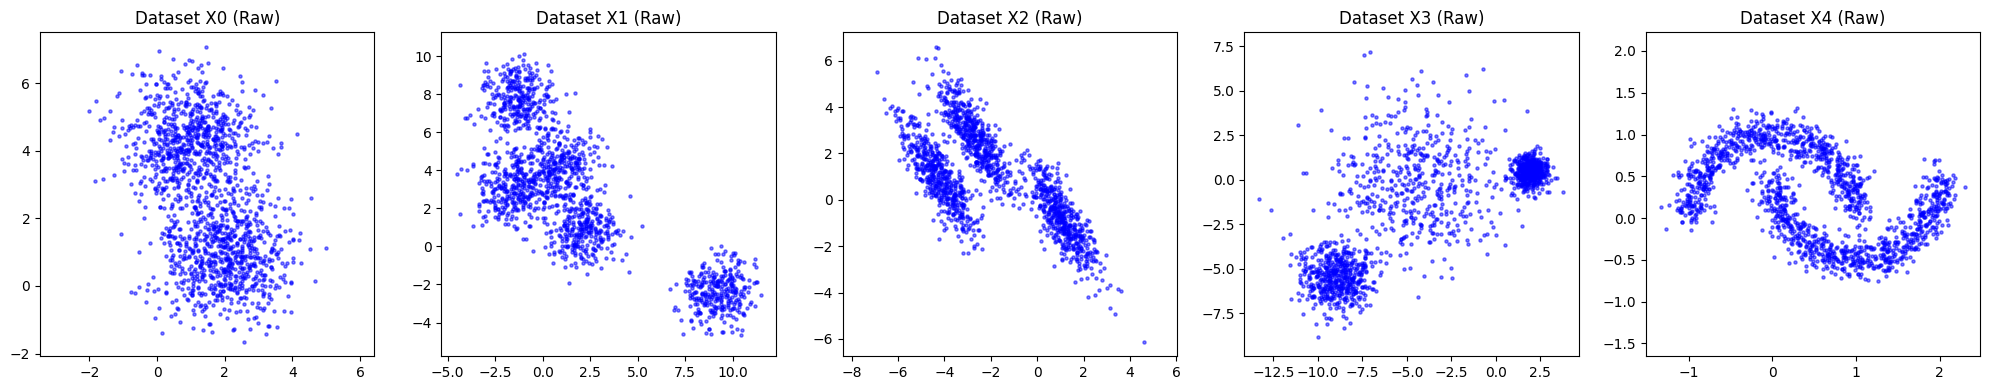

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, data in enumerate(X):
    axes[i].scatter(data[:, 0], data[:, 1], s=5, alpha=0.5, color='blue')
    axes[i].set_title(f'Dataset X{i} (Raw)')
    axes[i].axis('equal')
plt.tight_layout()
plt.show()

Elbow curves and choosing k

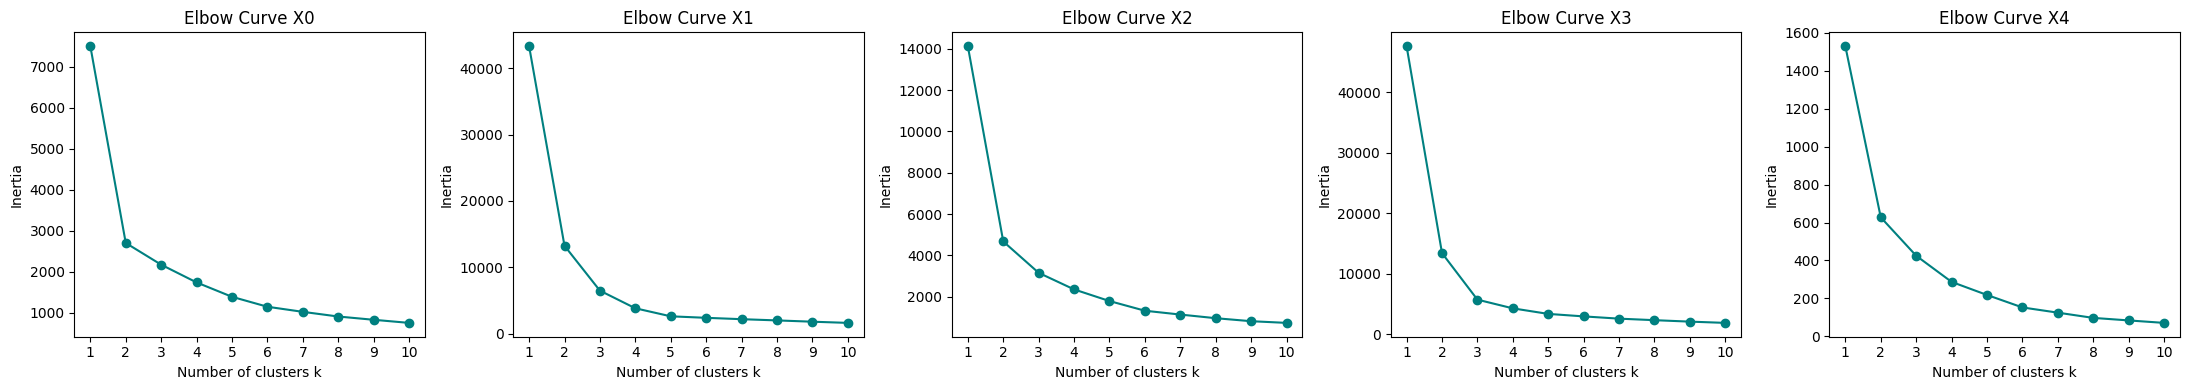

In [18]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, data in enumerate(X):
    inertias = []
    ks = range(1, 11)
    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
    
    axes[i].plot(ks, inertias, '-o', color='teal')
    axes[i].set_title(f'Elbow Curve X{i}')
    axes[i].set_xlabel('Number of clusters k')
    axes[i].set_ylabel('Inertia')
    axes[i].set_xticks(ks)

plt.tight_layout()
plt.show()

**Analyzing the Elbow curves**      

- X0: The elbow is very sharp at $k=2$. After 2, the rate of decrease in inertia slows down significantly.          
- X1: The elbow is clearly at $k=5$. This perfectly matches the 5 blobs we see in the raw data.         
- X2: The elbow is at $k=3$. However, the curve is a bit smoother than X1 because the clusters are elongated, making K-means slightly less efficient at every step.
- X3: The elbow is at $k=3$. Even though one cluster is much denser than the others, the mathematical bend occurs right after 3
- X4 (Moons): The elbow is technically at $k=2$, but notice the curve doesn't have a sharp drop followed by a flat line—it’s more of a gradual slope.


**K-means Clustering**

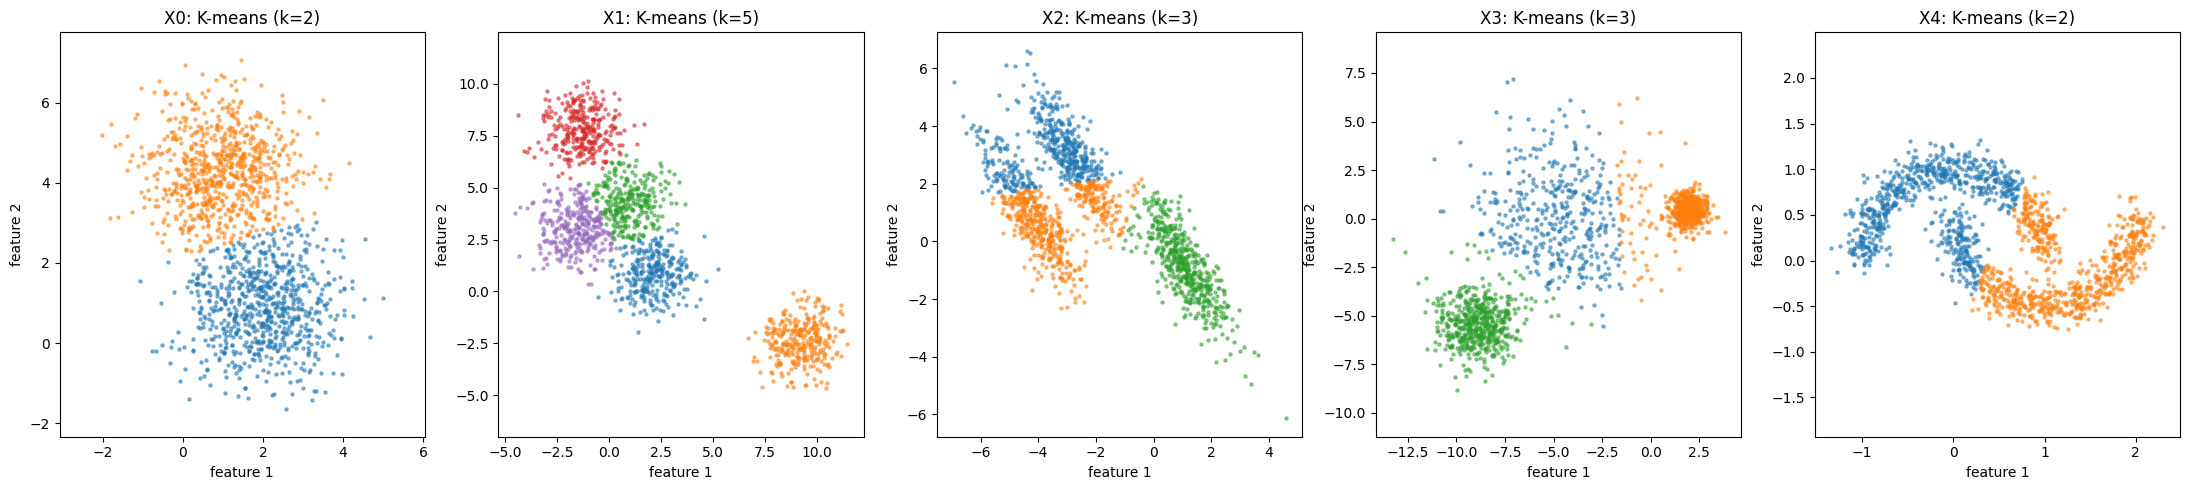

In [19]:
# Based on elbow curves and inspection
best_ks = [2, 5, 3, 3, 2] 

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, data in enumerate(X):
    k_val = best_ks[i]
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    plot_cluster(axes[i], data, labels)
    axes[i].set_title(f'X{i}: K-means (k={k_val})')

plt.tight_layout()
plt.show()

**2.2 Apply DBSCAN**

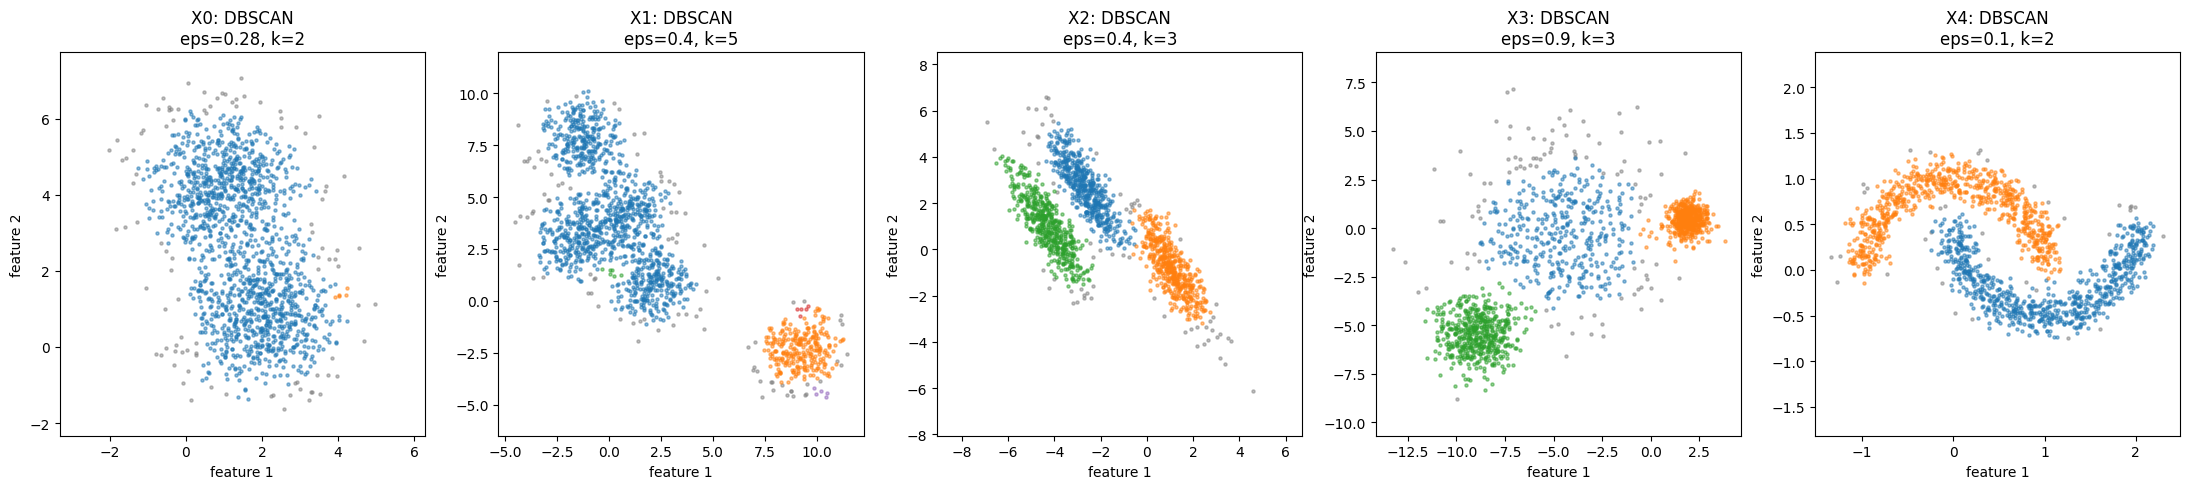

In [20]:
from sklearn.cluster import DBSCAN

dbscan_params = [
    (0.28, 5), 
    (0.4, 5), 
    (0.4, 10),
    (0.9, 15), 
    (0.1, 5)
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, (eps_val, min_val) in enumerate(dbscan_params):
    db = DBSCAN(eps=eps_val, min_samples=min_val)
    labels = db.fit_predict(X[i])
    plot_cluster(axes[i], X[i], labels)
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    axes[i].set_title(f'X{i}: DBSCAN\neps={eps_val}, k={n_clusters_}')

plt.tight_layout()
plt.show()

Extensive manual tuning was required to match the cluster counts obtained in the K-means section. For datasets $X_0$ through $X_3$, the algorithm was highly sensitive; small changes in eps often resulted in clusters either merging into one or fracturing into dozens of small groups.

**2.3 Apply Spectral Clustering**

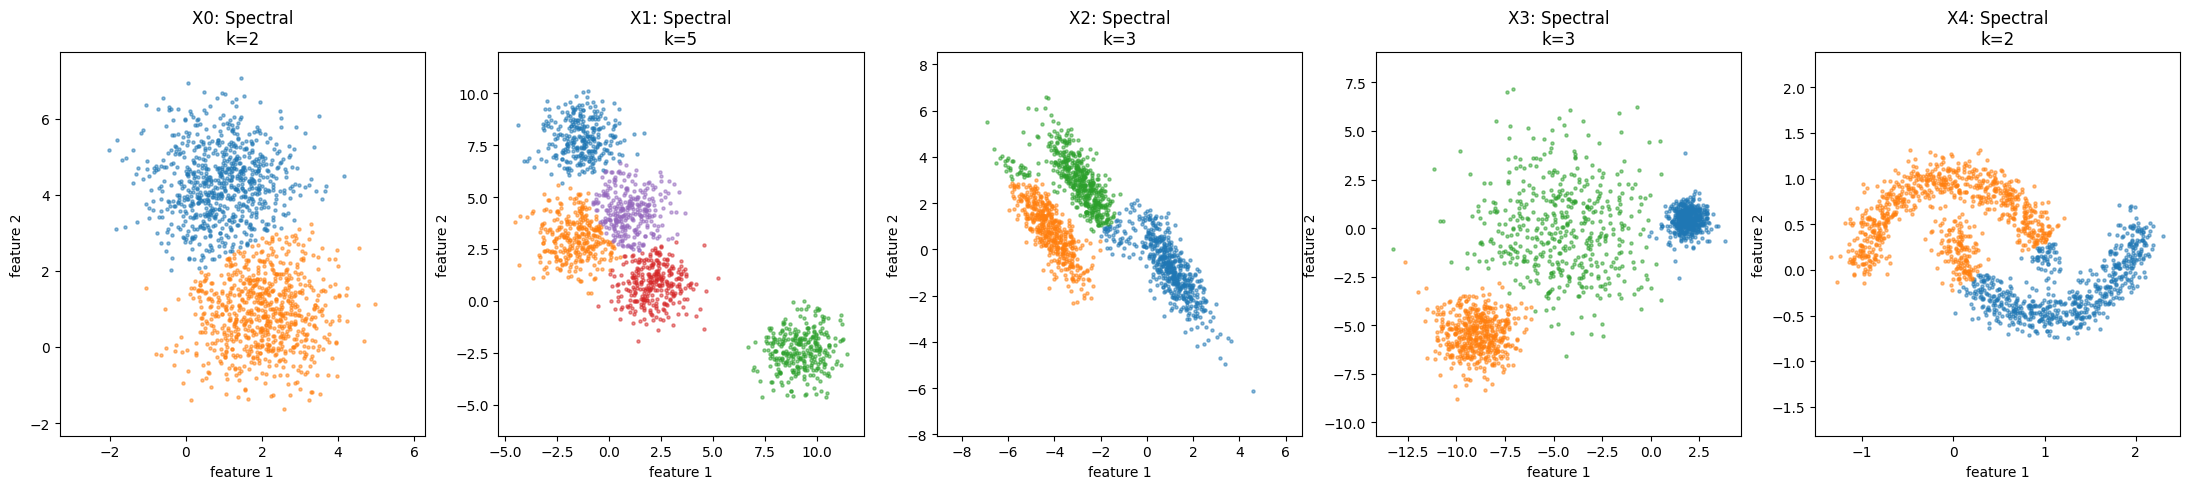

In [21]:
from sklearn.cluster import SpectralClustering

best_ks = [2, 5, 3, 3, 2]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, data in enumerate(X):
    sc = SpectralClustering(n_clusters=best_ks[i], affinity='nearest_neighbors', 
                            n_neighbors=10, random_state=42)
    labels = sc.fit_predict(data)
    
    plot_cluster(axes[i], data, labels)
    axes[i].set_title(f'X{i}: Spectral\nk={best_ks[i]}')

plt.tight_layout()
plt.show()

**2.4 Comparative Analysis**

Strengths and Weaknesses Summary

| Algorithm | Strengths | Weaknesses |
| :--- | :--- | :--- |
| **K-means** | Extremely fast and computationally efficient. Easy to implement and interpret. | Struggles with non-spherical shapes, varying densities, and is highly sensitive to outliers. |
| **DBSCAN** | Can find clusters of arbitrary shapes and effectively identifies noise/outliers. Does not require $k$ as an input. | Extremely sensitive to hyperparameters (`eps` and `min_samples`). Struggles with datasets of varying densities. |
| **Spectral Clustering** | Excellent at capturing complex geometric structures and global connectivity. More stable than DBSCAN. | Computationally expensive (slow for large datasets). Requires the number of clusters $k$ to be pre-defined. |


Best vs. Worst Performance

* **X0, X1:**
    * **Best:** **K-means**. It perfectly captured the spherical centers of the data.
    * **Worst:** **DBSCAN**. It was difficult to separate $X_0$ without merging the two close-proximity blobs or creating excessive noise.
* **X2:**
    * **Best:** **Spectral Clustering**. It successfully followed the "linear" connectivity of the elongated clusters.
    * **Worst:** **K-means**. It failed by attempting to partition the data into circular Voronoi cells, effectively cutting the long clusters.
* **X3:**
    * **Best:** **Spectral / K-means**. Both captured the three distinct regions well.
    * **Worst:** **DBSCAN**. Because the densities varied greatly, an eps that worked for the dense cluster often failed for the sparse ones, labeling them as noise.
* **X4:**
    * **Best:** **Spectral / DBSCAN**. Both successfully identified the non-linear manifold of the interlocking crescents.
    * **Worst:** **K-means**. Totally failed as it cannot handle non-convex shapes, splitting the moons in half based on distance to the centroid.

 Effort and Parameter Tuning

* **K-means (Low Effort):**
    The most straightforward process. Tuning only involved the **Elbow Method** to select $k$. While the elbow isn't always perfectly sharp (as seen in $X_4$), it provides a clear mathematical heuristic that requires little trial and error.
* **DBSCAN (High Effort):**
    Required the most manual intervention. As evidenced by the tuning of $X_0$ and $X_1$, a minute change in eps would cause the algorithm to swing from "over-segmenting" into many clusters to "under-segmenting" into a single group. Finding the parameter for each dataset was a labor-intensive process.
* **Spectral Clustering (Medium Effort):**
    The effort was balanced. It utilized the $k$ values already determined via K-means, removing the cluster count guesswork. While it requires choosing an affinity, it was much more robust and tuned out the noise issues seen in DBSCAN without constant parameter hunting.Computationally expensive (slow for large datasets). Requires the number of clusters $k$ to be pre-defined.

## Exercise 3 -Dimensionality reduction and visualization of digits with PCA and t-SNE

Provided code

In [22]:
################################
# Load the data
################################
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# load dataset
digits = datasets.load_digits()
n_sample = digits.target.shape[0]
n_feature = digits.images.shape[1] * digits.images.shape[2]
X_digits = np.zeros((n_sample, n_feature))
for i in range(n_sample):
    X_digits[i, :] = digits.images[i, :, :].flatten()
y_digits = digits.target

**3.1 Apply PCA and reduce the data, plot the data**        
For the digits dataset, pixel intensities range from 0 to 16. While the units are consistent across all features.       
I will standardization the data.

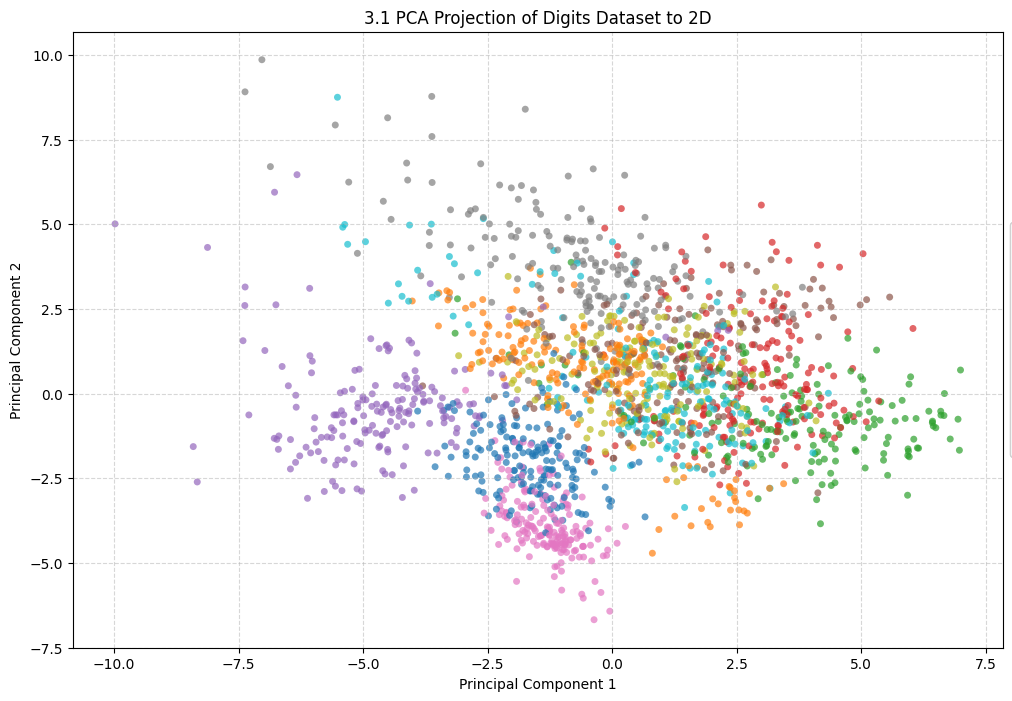

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Preprocessing: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# 2.  Reduce from 64 dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits,  cmap='tab10', alpha=0.7, s=25, edgecolor='none')

# Add Legend
legend1 = plt.legend(*scatter.legend_elements(), title="Digits", loc="center left", bbox_to_anchor=(1, 0.5))
plt.gca().add_artist(legend1)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('3.1 PCA Projection of Digits Dataset to 2D')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**3.2 Plotting he cumulative fraction of variance**

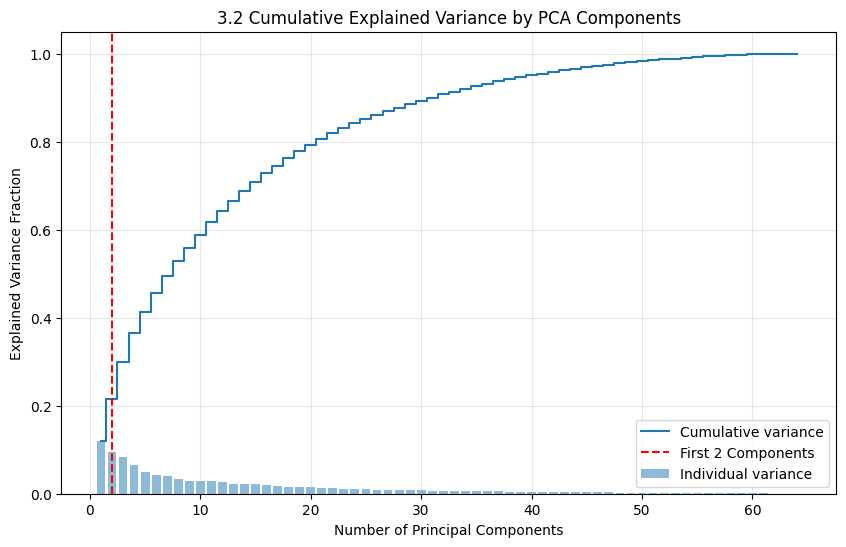

Variance explained by first 2 components: 0.2159
Variance UNEXPLAINED by first 2 components: 0.7841


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca_full = PCA().fit(X_scaled)
evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

# Plotting
plt.figure(figsize=(10, 6))
plt.step(range(1, len(cumulative_evr) + 1), cumulative_evr, where='mid', label='Cumulative variance')
plt.bar(range(1, len(evr) + 1), evr, alpha=0.5, align='center', label='Individual variance')

plt.axvline(x=2, color='r', linestyle='--', label='First 2 Components')
plt.ylabel('Explained Variance Fraction')
plt.xlabel('Number of Principal Components')
plt.title('3.2 Cumulative Explained Variance by PCA Components')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Counting the variance explained by the first 2 components
var_first_two = cumulative_evr[1]
unexplained_var = 1 - var_first_two

print(f"Variance explained by first 2 components: {var_first_two:.4f}")
print(f"Variance UNEXPLAINED by first 2 components: {unexplained_var:.4f}")

**1. What fraction of variance in the data is UNEXPLAINED by the first two principal components?**      
Based on the PCA analysis, the first two principal components explain approximately 21.59% of the total variance.       
Therefore, the fraction of variance that remains unexplained is 0.7841 (or 78.41%).

**2. Briefly comment on how this may impact how well-clustered the data are**           
The fact that over 78% of the variance is unexplained significantly limits the "well-clusteredness" of the 2D PCA plot.
Since PCA is a linera projection, forcing 64 dimensions into 2 while losing nearly 80% of the data's variance causes many distinct clusters to overlap.     
Many of the subtle pixel patterns that distinguish one digit from another are captured in the higher order components.      
By discarding them, the resulting 2D of the data lacks the detail necessary to separate the digits cleanly, leading to the cluttered appearance seen in the 3.1.

**3.3 Implement t-SNE Visualization**

Success! t-SNE completed.


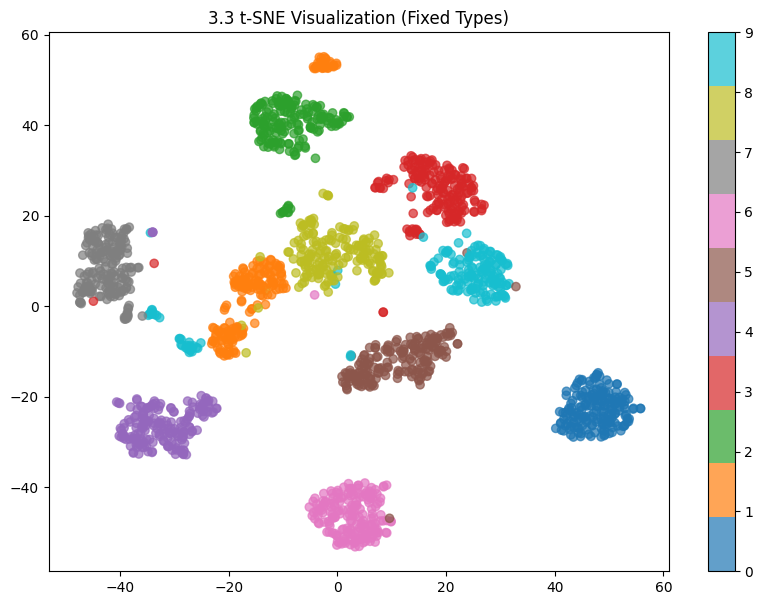

In [27]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Force a clean, numeric copy of the data
X_input = np.array(X_digits, copy=True, dtype=np.float64)
y_input = np.array(y_digits, copy=True, dtype=np.int32)

# 2. Reset the t-SNE parameters explicitly as floats
m_rate = float(200.0) 
perp = float(40.0)

tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000, 
    init='random', learning_rate=m_rate, random_state=42 )


X_tsne = tsne.fit_transform(X_input)
print("Success! t-SNE completed.")

# 4. Visualization
if 'X_tsne' in locals():
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_input, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter)
    plt.title("3.3 t-SNE Visualization (Fixed Types)")
    plt.show()


**3.4 Performance Comparison and Technical Analysis**       

**1. Which technique clustered the data best and why?**     
t-SNE clustered the data signigicantly better than PCA. It successfully separated that 10 digits into distinct islands. This is because t-SNE is a non-linear that focuses on preserving local structure.       

In constrast, PCA plot showed a dense cluster in the center with significant overlap.

**2. Why does t-SNE lack a separate transform method?**     
t-SNE is a non parametric and transductive algo. It does not learn a global mathematical function that can be saved and applied to new points.      
Instead, it optimizes the positions of the specific points provided during the fit process by minimizing hte KL-divergence between high and low dimentional probability distributions.

**3. What implications does this imply for using this method?**     
It means we cannot train t-SNE on a training set and then project a test set or a new incoming data point onto that same map. Also, because we cannot eseily apply it to new data, t-SNE is primarily a tool for EDA and visualization.